<a href="https://colab.research.google.com/github/d3au-4/Pokemon-Predictor-Dominic-and-Nicholas/blob/main/Pokemon_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
sold_price_path = kagglehub.dataset_download("ryanheger/pokemon-card-sold-price-reference")

print("Path to dataset files (sold_price_path):", sold_price_path)

price_charting_path = kagglehub.dataset_download("zeynepcahan/pokemon-pricecharting")

print("Path to dataset files:", price_charting_path)

print("Files in Dataset (pricecharting): ")

#############################################

for file in os.listdir(sold_price_path):
  print(file)

for file in os.listdir(price_charting_path):
  print(file)


print("Files in Dataset (sold price): ")

pricecharting_file = os.path.join(price_charting_path, "pokemon_pricecharting.csv")

#kaggle datasets
sold_file = os.path.join(sold_price_path, "gemsnipe-card-sold-price-reference.csv")
price_df = pd.read_csv(pricecharting_file)
sold_df = pd.read_csv(sold_file)

#tcg dataframe
tcg_df = pd.read_json("tcg_pokemon_cards_dataset.json")

#ebay dataframe
ebay_df = pd.read_json("pokemon_ebay_listings.json")

Using Colab cache for faster access to the 'pokemon-card-sold-price-reference' dataset.
Path to dataset files (sold_price_path): /kaggle/input/pokemon-card-sold-price-reference
Using Colab cache for faster access to the 'pokemon-pricecharting' dataset.
Path to dataset files: /kaggle/input/pokemon-pricecharting
Files in Dataset (pricecharting): 
gemsnipe-card-sold-price-reference.csv
pokemon_pricecharting.csv
Files in Dataset (sold price): 


In [14]:
SET_RELEASE_YEARS = {

    "pokemon-sun-&-moon": 2017,
    "pokemon-guardians-rising": 2017,
    "pokemon-burning-shadows": 2017,
    "pokemon-shining-legends": 2017,
    "pokemon-crimson-invasion": 2017,

    "pokemon-ultra-prism": 2018,
    "pokemon-forbidden-light": 2018,
    "pokemon-celestial-storm": 2018,
    "pokemon-dragon-majesty": 2018,
    "pokemon-lost-thunder": 2018,

    "pokemon-team-up": 2019,
    "pokemon-detective-pikachu": 2019,
    "pokemon-unbroken-bonds": 2019,
    "pokemon-unified-minds": 2019,
    "pokemon-hidden-fates": 2019,
    "pokemon-cosmic-eclipse": 2019,

    "pokemon-sword-&-shield": 2020,
    "pokemon-rebel-clash": 2020,
    "pokemon-darkness-ablaze": 2020,
    "pokemon-champion%27s-path": 2020,
    "pokemon-vivid-voltage": 2020,

    "pokemon-shining-fates": 2021,
    "pokemon-battle-styles": 2021,
    "pokemon-chilling-reign": 2021,
    "pokemon-evolving-skies": 2021,
    "pokemon-celebrations": 2021,
    "pokemon-fusion-strike": 2021,

    "pokemon-brilliant-stars": 2022,
    "pokemon-astral-radiance": 2022,
    "pokemon-pokemon-go": 2022,
    "pokemon-go": 2022,
    "pokemon-lost-origin": 2022,
    "pokemon-silver-tempest": 2022,

    "pokemon-crown-zenith": 2023,
    "pokemon-scarlet-&-violet": 2023,
    "pokemon-paldea-evolved": 2023,
    "pokemon-obsidian-flames": 2023,
    "pokemon-scarlet-&-violet-151": 2023,
    "pokemon-paradox-rift": 2023,

    "pokemon-temporal-forces": 2024,
    "pokemon-twilight-masquerade": 2024,
    "pokemon-shrouded-fable": 2024,
    "pokemon-stellar-crown": 2024,
    "pokemon-surging-sparks": 2024,

    "pokemon-prismatic-evolutions": 2025,
    "pokemon-journey-together": 2025,
    "pokemon-destined-rivals": 2025,
    "pokemon-black-bolt": 2025,
    "pokemon-white-flare": 2025
}

In [11]:
#print data
#Price Charting Visual
print("\nPriceCharting dataset:")
display(price_df.head())

print("\nColumns:")
display(price_df.columns)

print("\nShape:")
display(price_df.shape)

#Sold price visual
print("\nSold price dataset:")
display(sold_df.head())

print("\nColumns:")
display(sold_df.columns)

print("\nShape:")
display(sold_df.shape)

#display(tcg_df.head) visual

print("\nTCG dataset:")
display(tcg_df.head())

print("\nColumns:")
display(tcg_df.columns)

print("\nShape:")
display(tcg_df.shape)

#Ebay data

print("\nEbay Dataset:")
display(ebay_df.head())

print("\nColumns:")
display(ebay_df.columns)

print("\nShape:")
display(ebay_df.shape)






PriceCharting dataset:


,Unnamed: 0,Date_time,used_price,graded_price,prod_name,set_name,artist,is_popular_pokemon
0,0,1/1/2021 7:00,11.01,0.00,Umbreon_GX_#80,pokemon-sun-&-moon,NR,True
1,1,2/1/2021 7:00,9.43,81.99,Umbreon_GX_#80,pokemon-sun-&-moon,NR,True
2,2,3/1/2021 7:00,12.39,92.60,Umbreon_GX_#80,pokemon-sun-&-moon,NR,True
3,3,4/1/2021 6:00,12.25,159.07,Umbreon_GX_#80,pokemon-sun-&-moon,NR,True
4,4,5/1/2021 6:00,4.99,158.75,Umbreon_GX_#80,pokemon-sun-&-moon,NR,True



Columns:


Index(['Unnamed: 0', 'Date_time', 'used_price', 'graded_price', 'prod_name',
       'set_name', 'artist', 'is_popular_pokemon'],
      dtype='object')


Shape:


...

,title,price,condition,seller,url,image_url
0,Pokemon TCG Charizard ex EX FireRed & LeafGree...,"{'value': '650.00', 'currency': 'USD'}",Graded,"{'username': 'pokemo_30', 'feedbackPercentage'...",https://www.ebay.com/itm/318792214804?_skw=Cha...,https://i.ebayimg.com/images/g/jxgAAeSwFJZqkbW...
1,Pokemon TCG Mega Charizard X EX SIR 125/094 Ph...,"{'value': '95.99', 'currency': 'USD'}",Ungraded,"{'username': 'lyksorr87', 'feedbackPercentage'...",https://www.ebay.com/itm/287549404721?_skw=Cha...,https://i.ebayimg.com/images/g/4xcAAeSwj8NqkIu...
2,CHARIZARD EX HYPER RARE • PSA 9 MINT • 228/197...,"{'value': '150.00', 'currency': 'USD'}",Graded,"{'username': 'www.cullercollectibles', 'feedba...",https://www.ebay.com/itm/117383115484?_skw=Cha...,https://i.ebayimg.com/images/g/uG0AAeSwKX9qkat...
3,Pokemon TCG Dark Charizard Holo #6 1997 Japane...,"{'value': '249.99', 'currency': 'USD'}",Graded,"{'username': 'darkghost23', 'feedbackPercentag...",https://www.ebay.com/itm/307150117930?_skw=Cha...,https://i.ebayimg.com/images/g/sjcAAeSwyIRqkKG...
4,2019 Unbroken Bonds Reshiram Charizard GX #20/...,"{'value': '43.60', 'currency': 'USD'}",Graded,"{'username': 'cuddleskisses', 'feedbackPercent...",https://www.ebay.com/itm/158233218576?_skw=Cha...,https://i.ebayimg.com/images/g/1hYAAeSwMtZqkaT...



Columns:


Index(['title', 'price', 'condition', 'seller', 'url', 'image_url'], dtype='object')


Shape:


(8000, 6)

In [7]:
"""display(np.unique(price_df['set_name']))
display(np.unique(price_df['prod_name']))"""

"display(np.unique(price_df['set_name']))\ndisplay(np.unique(price_df['prod_name']))"

In [ ]:
"""umbreon_rows = price_df[price_df["prod_name"] == "Umbreon_GX_#80"]

umbreon_price = umbreon_rows['used_price']


plt.hist(umbreon_price, density=True, bins = np.arange(0,14))"""

######################

plt.figure(figsize=(10, 6))
plt.hist(price_df['used_price'], bins = 100)
plt.xlabel("Price of card(s)")
plt.ylabel("Number of Cards")
#plt.xticks(np.arange(0, 1501, 10))
plt.xlim(200, 1000)
plt.ylim(0, 225)




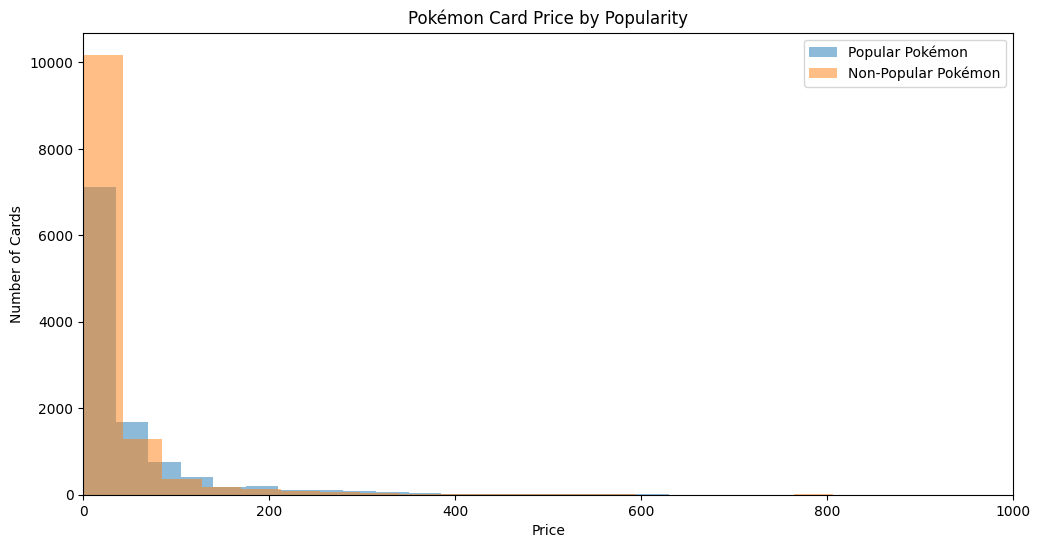

'plt.yticks(np.arange(0, 14001, 1000))\nplt.xticks(np.arange(0, 201, 10))'

In [6]:
plt.figure(figsize=(12, 6))

plt.hist(
    price_df[price_df["is_popular_pokemon"] == True]["used_price"],
    bins=50,
    alpha=0.5,
    label="Popular Pokémon"
)

plt.hist(
    price_df[price_df["is_popular_pokemon"] == False]["used_price"],
    bins=50,
    alpha=0.5,
    label="Non-Popular Pokémon"
)

plt.xlabel("Price")
plt.ylabel("Number of Cards")
plt.title("Pokémon Card Price by Popularity")

plt.xlim(0, 1000)
plt.legend()

plt.show()

"""plt.yticks(np.arange(0, 14001, 1000))
plt.xticks(np.arange(0, 201, 10))"""



In [ ]:
#price_df[price_df["prod_name"] == "Umbreon_GX_#80"]

In [12]:
price_df2 = price_df.copy()

# Convert dates into actual datetime objects
price_df2["Date_time"] = pd.to_datetime(price_df2["Date_time"])

# Remove unnecessary index column
if "Unnamed: 0" in price_df2.columns:
    price_df2 = price_df2.drop(columns=["Unnamed: 0"])

# Remove obviously unusable prices
price_df2["used_price"] = pd.to_numeric(price_df2["used_price"], errors="coerce")
price_df2["graded_price"] = pd.to_numeric(price_df2["graded_price"], errors="coerce")

print(price_df2.head())
print(price_df2.info())

            Date_time  used_price  graded_price       prod_name  \
0 2021-01-01 07:00:00       11.01          0.00  Umbreon_GX_#80   
1 2021-02-01 07:00:00        9.43         81.99  Umbreon_GX_#80   
2 2021-03-01 07:00:00       12.39         92.60  Umbreon_GX_#80   
3 2021-04-01 06:00:00       12.25        159.07  Umbreon_GX_#80   
4 2021-05-01 06:00:00        4.99        158.75  Umbreon_GX_#80   

             set_name artist  is_popular_pokemon  
0  pokemon-sun-&-moon     NR                True  
1  pokemon-sun-&-moon     NR                True  
2  pokemon-sun-&-moon     NR                True  
3  pokemon-sun-&-moon     NR                True  
4  pokemon-sun-&-moon     NR                True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23314 entries, 0 to 23313
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date_time           23314 non-null  datetime64[ns]
 1   used_price

In [ ]:
# Pull real Pokemon card catalog data from pokemontcg.io — no API key needed.
# Run this directly in Colab. This gives you real card metadata + images,
# which you'll combine with eBay listing prices once that access comes through.

import requests
import json
import time

BASE_URL = "https://api.pokemontcg.io/v2"

def fetch_with_retry(url, params, max_retries=4):
    """5xx errors from this API are usually transient — retry with
    increasing delays instead of failing immediately."""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=20)
            if response.status_code >= 500:  # any server-side error, not just 502
                wait = 2 ** attempt  # 1, 2, 4, 8 seconds
                print(f"  Got {response.status_code}, retrying in {wait}s... (attempt {attempt+1}/{max_retries})")
                time.sleep(wait)
                continue
            response.raise_for_status()
            return response
        except requests.exceptions.Timeout:
            wait = 2 ** attempt
            print(f"  Timed out, retrying in {wait}s... (attempt {attempt+1}/{max_retries})")
            time.sleep(wait)
    return None  # signal total failure instead of raising, so caller can fall back


def fetch_all_sets():
    """Get the list of all sets first — we'll pull cards set-by-set instead
    of one giant unfiltered request, since the API struggles with that."""
    response = fetch_with_retry(f"{BASE_URL}/sets", {"pageSize": 250})
    if response is None:
        return []
    return response.json().get("data", [])


def fetch_all_cards_by_set():
    """Pulls the full card database by looping through each set individually.
    Much more reliable than one unfiltered request for ~19,000 cards —
    smaller requests are less likely to time out or trigger server errors."""
    sets = fetch_all_sets()
    print(f"Found {len(sets)} sets to pull cards from.\n")

    all_cards = []
    for i, s in enumerate(sets, start=1):
        set_id = s["id"]
        set_name = s["name"]
        cards = fetch_cards(query=f"set.id:{set_id}", page_size=250, max_pages=None)
        all_cards.extend(cards)
        print(f"[{i}/{len(sets)}] {set_name}: {len(cards)} cards (running total: {len(all_cards)})\n")

    return all_cards
    """Fetch cards matching a search query, looping through ALL pages until
    the API returns fewer cards than page_size (meaning we hit the end).
    page_size=250 is this API's max per request.
    max_pages=None means "keep going until there's nothing left" —
    set it to a number if you want to cap how much you pull for testing."""
    all_cards = []
    page = 1
    while True:
        if max_pages is not None and page > max_pages:
            break

        params = {
            "q": query,
            "pageSize": page_size,
            "page": page,
        }
        response = fetch_with_retry(f"{BASE_URL}/cards", params)
        if response is None:
            print(f"  All retries exhausted on page {page} — stopping here.")
            break

        data = response.json()
        batch = data.get("data", [])
        all_cards.extend(batch)
        total_count = data.get("totalCount", "?")
        print(f"  Page {page}: got {len(batch)} cards (total so far: {len(all_cards)} / {total_count})")

        # be polite to the free tier — small delay between pages
        time.sleep(0.3)

        if len(batch) < page_size:
            break  # last page — fewer cards than a full page means we're done

        page += 1

    return all_cards


def build_dataset(cards):
    """Flattens the raw API response into a clean dataset for your scoring pipeline."""
    rows = []
    for card in cards:
        tcgplayer_prices = card.get("tcgplayer", {}).get("prices", {})
        rows.append({
            "id": card.get("id"),
            "name": card.get("name"),
            "set_name": card.get("set", {}).get("name"),
            "set_release_date": card.get("set", {}).get("releaseDate"),
            "rarity": card.get("rarity"),
            "number": card.get("number"),
            "image_small": card.get("images", {}).get("small"),
            "image_large": card.get("images", {}).get("large"),
            # TCGplayer market price data IS included on pokemontcg.io cards
            # for free, even without the closed TCGplayer API — this is huge,
            # it means you don't need separate TCGplayer access at all.
            "market_price": tcgplayer_prices.get("holofoil", {}).get("market")
                            or tcgplayer_prices.get("normal", {}).get("market"),
            "low_price": tcgplayer_prices.get("holofoil", {}).get("low")
                         or tcgplayer_prices.get("normal", {}).get("low"),
            "high_price": tcgplayer_prices.get("holofoil", {}).get("high")
                          or tcgplayer_prices.get("normal", {}).get("high"),
        })
    return rows


FALLBACK_CARDS = [
    {"id": "base1-4", "name": "Charizard", "set": {"name": "Base Set", "releaseDate": "1999/01/09"},
     "rarity": "Rare Holo", "number": "4",
     "images": {"small": "https://images.pokemontcg.io/base1/4.png", "large": "https://images.pokemontcg.io/base1/4_hires.png"},
     "tcgplayer": {"prices": {"holofoil": {"market": 350.00, "low": 220.00, "high": 900.00}}}},
    {"id": "base1-4-shadowless", "name": "Charizard (Shadowless)", "set": {"name": "Base Set", "releaseDate": "1999/01/09"},
     "rarity": "Rare Holo", "number": "4",
     "images": {"small": "https://images.pokemontcg.io/base1/4.png", "large": "https://images.pokemontcg.io/base1/4_hires.png"},
     "tcgplayer": {"prices": {"holofoil": {"market": 1200.00, "low": 800.00, "high": 3500.00}}}},
]


if __name__ == "__main__":
    print("Fetching ALL Pokemon cards from pokemontcg.io, set by set (this will take a few minutes)...\n")
    cards = fetch_all_cards_by_set()

    if not cards:
        print("Live API unavailable right now — using a small fallback dataset instead")
        print("so you can keep building. Re-run this later to get real live data.")
        cards = FALLBACK_CARDS
    else:
        print(f"\nRetrieved {len(cards)} total cards from the live API")

    dataset = build_dataset(cards)

    # Save to JSON so you can load it in your scoring pipeline
    with open("all_pokemon_cards_dataset.json", "w") as f:
        json.dump(dataset, f, indent=2)

    print("\nSample results:")
    for row in dataset[:5]:
        print(f"  {row['name']} ({row['set_name']}, {row['rarity']}) — market: ${row['market_price']}")

    print(f"\nSaved {len(dataset)} cards to all_pokemon_cards_dataset.json")